In [89]:
import os
import platform
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [90]:
P3 = "../../images/p3"

paths = {
    "A_in":  os.path.join(P3, "field_in.png"),
    "A_out": os.path.join(P3, "field_out_A.png"),

    "B_in":  os.path.join(P3, "field_in.png"),
    "B_out": os.path.join(P3, "field_out_B.png"),

    "C_in":  os.path.join(P3, "nebula_in.png"),
    "C_out": os.path.join(P3, "nebula_out_C.png"),

    "D_in":  os.path.join(P3, "field_skycrop_in.png"),
    "D_out": os.path.join(P3, "field_skycrop_out_D.png"),
}

In [91]:
def load_gray(path):
    img = np.array(Image.open(path))

    if img.ndim != 2:
        raise ValueError(f"{path} is not grayscale: shape={img.shape}")

    if img.dtype != np.uint8:
        raise ValueError(f"{path} is not uint8: dtype={img.dtype}")

    return img


images = {name: load_gray(path) for name, path in paths.items()}

for name, img in images.items():
    print(
        f"{name:6s}: "
        f"shape={img.shape}, "
        f"dtype={img.dtype}, "
        f"min={img.min()}, "
        f"max={img.max()}"
    )

A_in  : shape=(872, 1000), dtype=uint8, min=0, max=255
A_out : shape=(872, 1000), dtype=uint8, min=0, max=255
B_in  : shape=(872, 1000), dtype=uint8, min=0, max=255
B_out : shape=(872, 1000), dtype=uint8, min=0, max=235
C_in  : shape=(1600, 1600), dtype=uint8, min=1, max=255
C_out : shape=(1600, 1600), dtype=uint8, min=5, max=255
D_in  : shape=(200, 200), dtype=uint8, min=0, max=246
D_out : shape=(200, 200), dtype=uint8, min=0, max=253


In [92]:
def transfer_curve(img_in, img_out):

    if img_in.shape != img_out.shape:
        raise ValueError("Input and output images must have the same shape.")

    x = img_in.ravel().astype(np.int64)
    y = img_out.ravel().astype(np.float64)

    cnt = np.bincount(x, minlength=256)

    sums = np.bincount(
        x,
        weights=y,
        minlength=256
    )

    T = np.full(256, np.nan, dtype=np.float64)

    observed = cnt > 0
    T[observed] = sums[observed] / cnt[observed]

    return T, cnt

In [93]:
TA, cntA = transfer_curve(images["A_in"], images["A_out"])
TB, cntB = transfer_curve(images["B_in"], images["B_out"])
TC, cntC = transfer_curve(images["C_in"], images["C_out"])
TD, cntD = transfer_curve(images["D_in"], images["D_out"])

In [94]:
for name, T, cnt in [
    ("A", TA, cntA),
    ("B", TB, cntB),
    ("C", TC, cntC),
    ("D", TD, cntD),
]:
    observed = cnt > 0

    print(
        name,
        "observed levels:",
        observed.sum(),
        "/ 256",
        "range:",
        np.where(observed)[0].min(),
        "to",
        np.where(observed)[0].max()
    )

A observed levels: 256 / 256 range: 0 to 255
B observed levels: 256 / 256 range: 0 to 255
C observed levels: 254 / 256 range: 1 to 255
D observed levels: 239 / 256 range: 0 to 246


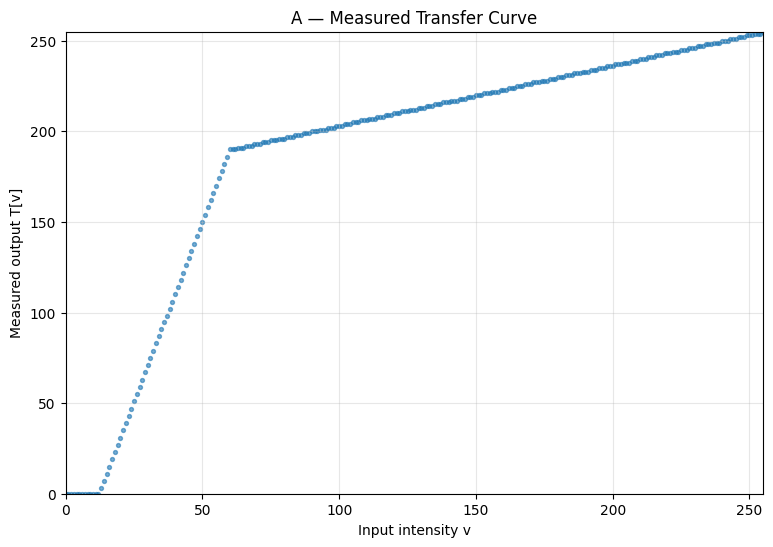

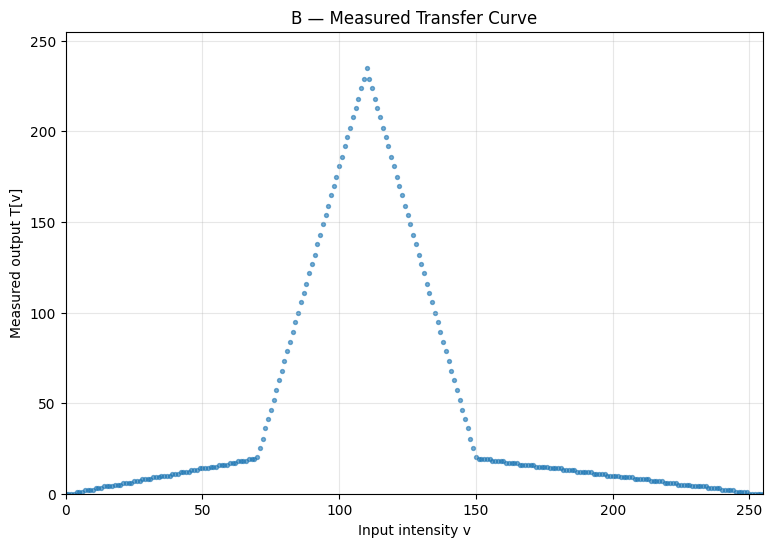

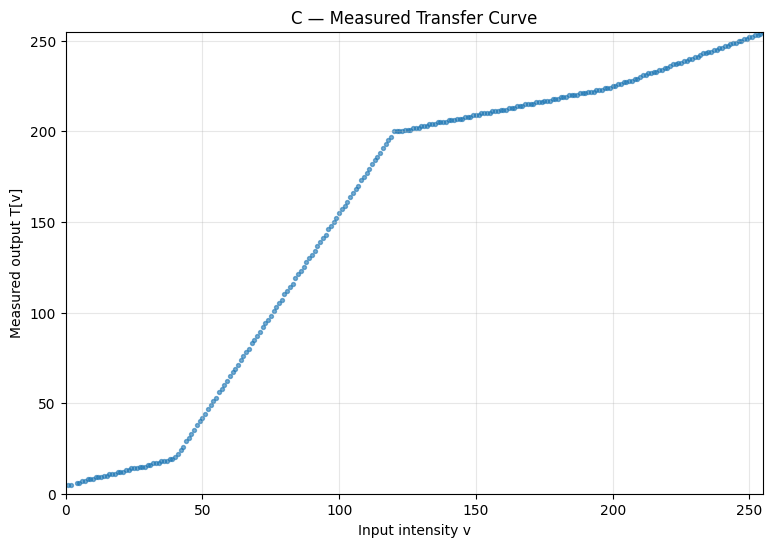

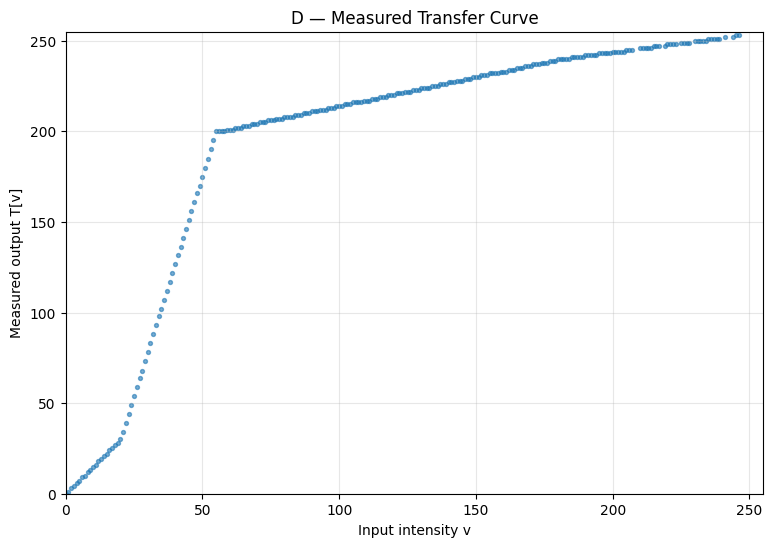

In [95]:
def plot_transfer(T, cnt, title):
    levels = np.arange(256)
    mask = cnt > 0

    plt.figure(figsize=(9, 6))

    plt.scatter(
        levels[mask],
        T[mask],
        s=8,
        alpha=0.6
    )

    plt.xlabel("Input intensity v")
    plt.ylabel("Measured output T[v]")
    plt.title(title)
    plt.xlim(0, 255)
    plt.ylim(0, 255)
    plt.grid(True, alpha=0.3)
    plt.show()


plot_transfer(TA, cntA, "A — Measured Transfer Curve")
plot_transfer(TB, cntB, "B — Measured Transfer Curve")
plot_transfer(TC, cntC, "C — Measured Transfer Curve")
plot_transfer(TD, cntD, "D — Measured Transfer Curve")

In [96]:
def weighted_line_fit(T, cnt, lo, hi):
    """
    Fit y = m*x + c over input levels [lo, hi].

    Only levels with cnt > 0 participate.
    Pixel counts are used as weights.
    """

    levels = np.arange(lo, hi + 1)

    mask = (
        (cnt[levels] > 0) &
        np.isfinite(T[levels])
    )

    x = levels[mask].astype(np.float64)
    y = T[levels][mask]
    w = cnt[levels][mask].astype(np.float64)

    if len(x) == 0:
        return np.nan, np.nan, np.inf

    # Weighted least squares.
    W = np.sum(w)
    xbar = np.sum(w * x) / W
    ybar = np.sum(w * y) / W

    denom = np.sum(w * (x - xbar)**2)

    if denom == 0:
        m = 0.0
    else:
        m = np.sum(w * (x - xbar) * (y - ybar)) / denom

    c = ybar - m * xbar

    residual = y - (m * x + c)
    sse = np.sum(w * residual**2)

    return m, c, sse

In [97]:
def fit_piecewise(T, cnt, max_seg=6):
    """
    Fit a piecewise-linear transform using dynamic programming.

    The selected model minimizes a BIC-like criterion with a quantisation
    variance floor of 1/12.

    Returns
    -------
    breakpoints : list
        Internal breakpoints between segments.
    slopes : list
        Slope of each segment.
    intercepts : list
        Intercept of each segment.
    n_segments : int
        Selected number of segments.
    """

    levels = np.arange(256)

    supported = np.where(
        (cnt > 0) & np.isfinite(T)
    )[0]

    if len(supported) < 2:
        raise ValueError("Not enough supported intensity levels.")

    lo = int(supported.min())
    hi = int(supported.max())

    N = int(cnt[supported].sum())

    # Quantisation variance for rounding to nearest integer.
    quant_var = 1.0 / 12.0

    # Precompute fitting cost for every interval.
    interval_cost = np.full((256, 256), np.inf)
    interval_fit = {}

    for a in range(lo, hi + 1):
        for b in range(a, hi + 1):

            m, c, sse = weighted_line_fit(T, cnt, a, b)

            if np.isfinite(sse):
                interval_cost[a, b] = sse
                interval_fit[(a, b)] = (m, c)

    # dp[k, b] = best SSE using k segments ending at b.
    dp = np.full((max_seg + 1, 256), np.inf)
    prev = np.full((max_seg + 1, 256), -1, dtype=int)

    dp[0, lo - 1] = 0.0

    for k in range(1, max_seg + 1):

        for b in range(lo, hi + 1):

            best_cost = np.inf
            best_a = -1

            for a in range(lo, b + 1):

                if a == lo:
                    previous = 0.0 if k == 1 else np.inf
                else:
                    previous = dp[k - 1, a - 1]

                if not np.isfinite(previous):
                    continue

                cost = previous + interval_cost[a, b]

                if cost < best_cost:
                    best_cost = cost
                    best_a = a

            dp[k, b] = best_cost
            prev[k, b] = best_a

    # Evaluate models using a BIC-like criterion.
    model_scores = []

    for k in range(1, max_seg + 1):

        sse = dp[k, hi]

        if not np.isfinite(sse):
            continue

        # 2 parameters per line: slope and intercept.
        p = 2 * k

        variance = max(sse / N, quant_var)

        score = N * np.log(variance) + p * np.log(N)

        model_scores.append((score, k, sse))

    # Choose the smallest score.
    _, best_k, best_sse = min(model_scores, key=lambda z: z[0])

    # Recover boundaries.
    segments = []

    b = hi

    for k in range(best_k, 0, -1):

        a = prev[k, b]

        if a < 0:
            raise RuntimeError("Failed to reconstruct segmentation.")

        segments.append((a, b))
        b = a - 1

    segments.reverse()

    slopes = []
    intercepts = []

    for a, b in segments:
        m, c = interval_fit[(a, b)]
        slopes.append(m)
        intercepts.append(c)

    breakpoints = [
        segments[i][1]
        for i in range(len(segments) - 1)
    ]

    return breakpoints, slopes, intercepts, best_k

In [98]:
def apply_recovered(img, bps, slopes, inter):
    """
    Build a 256-entry LUT from the recovered piecewise-linear transform
    and apply it to an 8-bit grayscale image.
    """

    img = np.asarray(img)

    if img.dtype != np.uint8:
        raise ValueError("Expected uint8 image.")

    if len(slopes) != len(inter):
        raise ValueError("slopes and intercepts must have same length.")

    if len(bps) != len(slopes) - 1:
        raise ValueError(
            "Need exactly n_segments - 1 breakpoints."
        )

    # Construct boundaries.
    boundaries = [0] + list(bps) + [255]

    lut = np.zeros(256, dtype=np.float64)

    for i in range(len(slopes)):

        start = boundaries[i]
        end = boundaries[i + 1]

        m = slopes[i]
        c = inter[i]

        lut[start:end + 1] = m * np.arange(
            start,
            end + 1
        ) + c

    # Clip and round to valid 8-bit values.
    lut = np.clip(lut, 0, 255)
    lut = np.rint(lut).astype(np.uint8)

    return lut[img]

In [99]:
def reconstruction_error(pred, true):
    diff = np.abs(
        pred.astype(np.int16) -
        true.astype(np.int16)
    )

    return {
        "max_abs_error": int(diff.max()),
        "mean_abs_error": float(diff.mean()),
    }

In [100]:
def fitted_curve(bps, slopes, inter):
    boundaries = [0] + list(bps) + [255]

    x = np.arange(256)
    y = np.zeros(256, dtype=np.float64)

    for i, (m, c) in enumerate(zip(slopes, inter)):
        a = boundaries[i]
        b = boundaries[i + 1]

        y[a:b + 1] = m * x[a:b + 1] + c

    return x, y

In [101]:
def plot_fit(T, cnt, bps, slopes, inter, title):

    levels = np.arange(256)
    mask = cnt > 0

    xfit, yfit = fitted_curve(
        bps, slopes, inter
    )

    plt.figure(figsize=(9, 6))

    plt.scatter(
        levels[mask],
        T[mask],
        s=8,
        alpha=0.5,
        label="Measured T[v]"
    )

    plt.plot(
        xfit,
        yfit,
        linewidth=2,
        label="Piecewise-linear fit"
    )

    for bp in bps:
        plt.axvline(
            bp,
            linestyle="--",
            alpha=0.6
        )

    plt.xlabel("Input intensity")
    plt.ylabel("Output intensity")
    plt.title(title)
    plt.xlim(0, 255)
    plt.ylim(0, 255)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [102]:
bps_A, slopes_A, inter_A, n_A = fit_piecewise(
    TA,
    cntA,
    max_seg=6
)

print("A")
print("Number of segments:", n_A)
print("Breakpoints:", bps_A)
print("Slopes:", slopes_A)
print("Intercepts:", inter_A)

A
Number of segments: 3
Breakpoints: [np.int64(12), np.int64(60)]
Slopes: [np.float64(0.0), np.float64(3.9776565806187154), np.float64(0.3333113388105286)]
Intercepts: [np.float64(0.0), np.float64(-48.62446902489302), np.float64(169.6688248147177)]


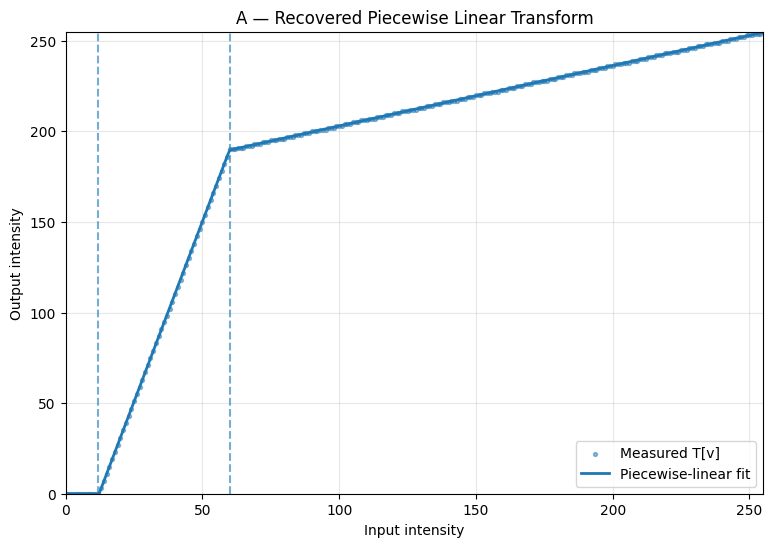

In [103]:
plot_fit(
    TA,
    cntA,
    bps_A,
    slopes_A,
    inter_A,
    "A — Recovered Piecewise Linear Transform"
)

In [104]:
A_recovered = apply_recovered(
    images["A_in"],
    bps_A,
    slopes_A,
    inter_A
)

err_A = reconstruction_error(
    A_recovered,
    images["A_out"]
)

print(err_A)

{'max_abs_error': 1, 'mean_abs_error': 0.005822247706422018}


In [105]:
def segment_table(bps, slopes, inter):

    boundaries = [0] + list(bps) + [255]

    rows = []

    for i, (m, c) in enumerate(zip(slopes, inter)):

        rows.append({
            "segment": i + 1,
            "input_start": boundaries[i],
            "input_end": boundaries[i + 1],
            "slope": m,
            "intercept": c
        })

    return rows


segment_table(
    bps_A,
    slopes_A,
    inter_A
)

[{'segment': 1,
  'input_start': 0,
  'input_end': np.int64(12),
  'slope': np.float64(0.0),
  'intercept': np.float64(0.0)},
 {'segment': 2,
  'input_start': np.int64(12),
  'input_end': np.int64(60),
  'slope': np.float64(3.9776565806187154),
  'intercept': np.float64(-48.62446902489302)},
 {'segment': 3,
  'input_start': np.int64(60),
  'input_end': 255,
  'slope': np.float64(0.3333113388105286),
  'intercept': np.float64(169.6688248147177)}]

In [106]:
bps_B, slopes_B, inter_B, n_B = fit_piecewise(
    TB,
    cntB,
    max_seg=6
)

print("B")
print("Number of segments:", n_B)
print("Breakpoints:", bps_B)
print("Slopes:", slopes_B)
print("Intercepts:", inter_B)

B
Number of segments: 4
Breakpoints: [np.int64(69), np.int64(109), np.int64(150)]
Slopes: [np.float64(0.2855122711463147), np.float64(5.37293379175466), np.float64(-5.374621119825842), np.float64(-0.19027546785473448)]
Intercepts: [np.float64(-0.4258892102440468), np.float64(-356.50053013656714), np.float64(825.7753276282598), np.float64(48.05085899530808)]


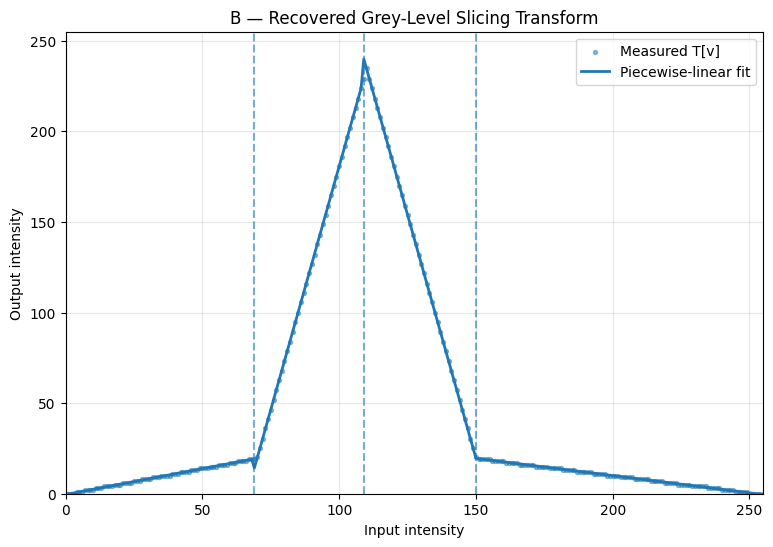

In [107]:
plot_fit(
    TB,
    cntB,
    bps_B,
    slopes_B,
    inter_B,
    "B — Recovered Grey-Level Slicing Transform"
)

In [108]:
B_recovered = apply_recovered(
    images["B_in"],
    bps_B,
    slopes_B,
    inter_B
)

err_B = reconstruction_error(
    B_recovered,
    images["B_out"]
)

print(err_B)

{'max_abs_error': 11, 'mean_abs_error': 0.005494266055045872}


A: max absolute error = 1, mean absolute error = 0.005822
B: max absolute error = 11, mean absolute error = 0.005494


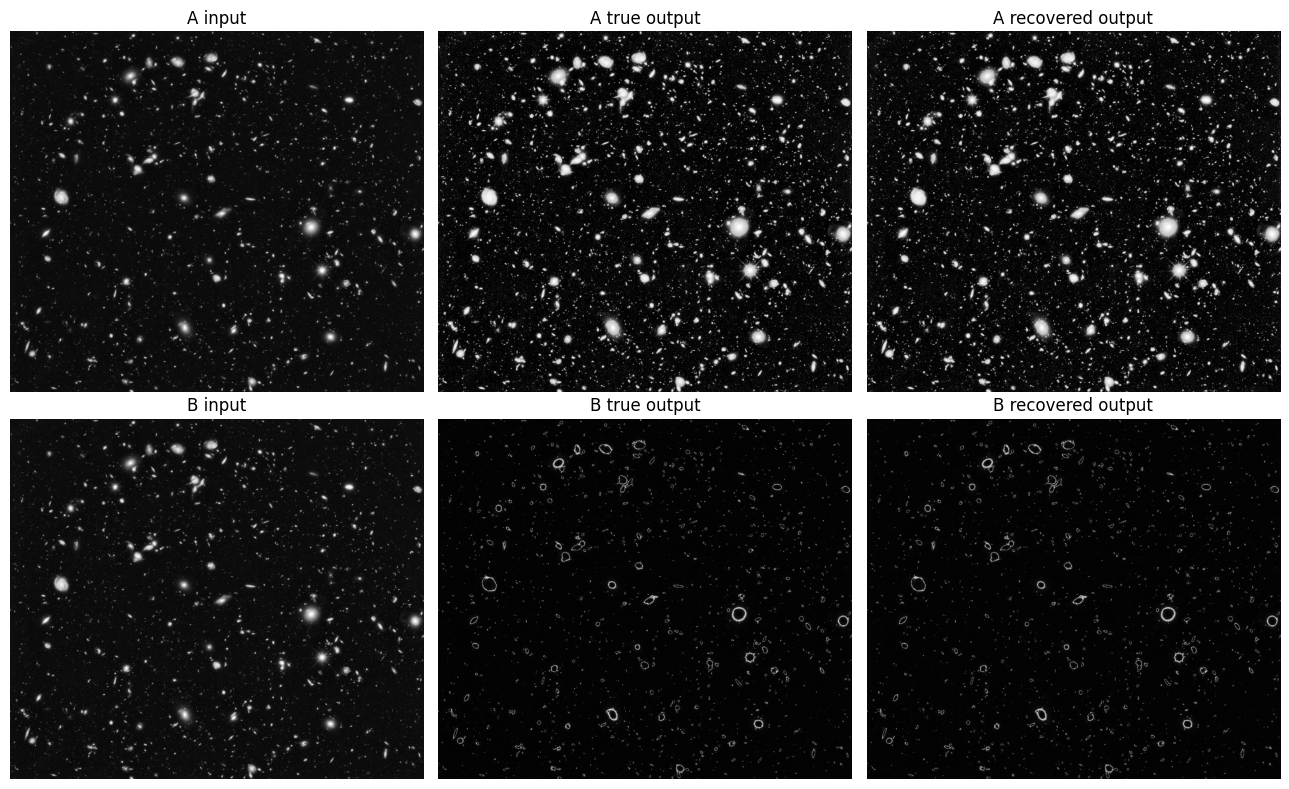

In [109]:
# 3.1 — Reapply the recovered maps and measure reconstruction error.
A_recovered = apply_recovered(
    images["A_in"],
    bps_A,
    slopes_A,
    inter_A
)

B_recovered = apply_recovered(
    images["B_in"],
    bps_B,
    slopes_B,
    inter_B
)

errors_31 = {
    "A": reconstruction_error(A_recovered, images["A_out"]),
    "B": reconstruction_error(B_recovered, images["B_out"]),
}

for name, error in errors_31.items():
    print(
        f"{name}: max absolute error = {error['max_abs_error']}, "
        f"mean absolute error = {error['mean_abs_error']:.6f}"
    )

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for row, name in enumerate(("A", "B")):
    input_image = images[f"{name}_in"]
    true_output = images[f"{name}_out"]
    recovered_output = locals()[f"{name}_recovered"]

    for axis, image, title in zip(
        axes[row],
        (input_image, true_output, recovered_output),
        (f"{name} input", f"{name} true output", f"{name} recovered output"),
    ):
        axis.imshow(image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(title)
        axis.axis("off")

plt.tight_layout()
plt.show()

**Recoverable vs. invertible:** B is recoverable because the input-output pair reveals its mapping, but it is not invertible from the output alone because grey-level slicing is non-monotonic and multiple input levels can map to the same output level.

In [110]:
diff_B = np.abs(
    B_recovered.astype(np.int16) -
    images["B_out"].astype(np.int16)
)

idx = np.unravel_index(np.argmax(diff_B), diff_B.shape)

print("Maximum-error location:", idx)
print("Input:", images["B_in"][idx])
print("True output:", images["B_out"][idx])
print("Recovered output:", B_recovered[idx])

Maximum-error location: (np.int64(18), np.int64(734))
Input: 109
True output: 229
Recovered output: 240


In [111]:
def model_scores(T, cnt, max_seg=6):

    # We'll use the same fitting machinery but explicitly evaluate
    # each candidate number of segments.

    supported = np.where(
        (cnt > 0) & np.isfinite(T)
    )[0]

    lo = int(supported.min())
    hi = int(supported.max())

    N = int(cnt[supported].sum())
    quant_var = 1.0 / 12.0

    interval_cost = np.full((256, 256), np.inf)

    for a in range(lo, hi + 1):
        for b in range(a, hi + 1):

            _, _, sse = weighted_line_fit(
                T, cnt, a, b
            )

            interval_cost[a, b] = sse

    dp = np.full((max_seg + 1, 256), np.inf)

    dp[0, lo - 1] = 0.0

    for k in range(1, max_seg + 1):

        for b in range(lo, hi + 1):

            for a in range(lo, b + 1):

                if a == lo:
                    previous = 0.0 if k == 1 else np.inf
                else:
                    previous = dp[k - 1, a - 1]

                if np.isfinite(previous):

                    value = (
                        previous +
                        interval_cost[a, b]
                    )

                    if value < dp[k, b]:
                        dp[k, b] = value

    results = []

    for k in range(1, max_seg + 1):

        sse = dp[k, hi]

        if np.isfinite(sse):

            variance = max(
                sse / N,
                quant_var
            )

            p = 2 * k

            score = (
                N * np.log(variance)
                + p * np.log(N)
            )

            results.append({
                "segments": k,
                "SSE": sse,
                "score": score
            })

    return results

In [123]:
scores_C = model_scores(
    TC,
    cntC,
    max_seg=6
)

for row in scores_C:
    print(row)

{'segments': 1, 'SSE': np.float64(1157459570.361211), 'score': np.float64(15651807.043055516)}
{'segments': 2, 'SSE': np.float64(12673358.956110198), 'score': np.float64(4094765.739985801)}
{'segments': 3, 'SSE': np.float64(1216076.2439959524), 'score': np.float64(-1905518.5741149473)}
{'segments': 4, 'SSE': np.float64(202279.41624593228), 'score': np.float64(-6361242.97931475)}
{'segments': 5, 'SSE': np.float64(195010.5936402336), 'score': np.float64(-6361213.468279117)}
{'segments': 6, 'SSE': np.float64(189254.58776617644), 'score': np.float64(-6361183.9572434835)}


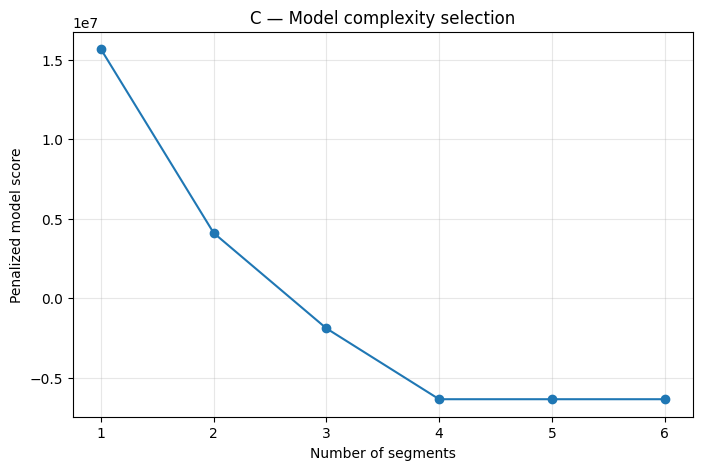

In [124]:
k = [r["segments"] for r in scores_C]
score = [r["score"] for r in scores_C]

plt.figure(figsize=(8, 5))
plt.plot(k, score, marker="o")
plt.xlabel("Number of segments")
plt.ylabel("Penalized model score")
plt.title("C — Model complexity selection")
plt.xticks(k)
plt.grid(True, alpha=0.3)
plt.show()

In [125]:
# 3.2 — Recover the model parameters at the selected complexity.
best_model_C = min(
    scores_C,
    key=lambda row: row["score"]
)
best_k_C = best_model_C["segments"]

bps_C, slopes_C, inter_C, n_C = fit_piecewise(
    TC,
    cntC,
    max_seg=best_k_C
)

print("Selected number of segments:", n_C)
print("Selected model score:", best_model_C["score"])
print("Selected model SSE:", best_model_C["SSE"])
print("Breakpoints:", bps_C)
print()

for index, (slope, intercept) in enumerate(zip(slopes_C, inter_C), start=1):
    if index == 1:
        input_start = 0
    else:
        input_start = int(bps_C[index - 2]) + 1

    if index == len(slopes_C):
        input_end = 255
    else:
        input_end = int(bps_C[index - 1])

    print(
        f"Segment {index}: input {input_start}-{input_end}, "
        f"slope = {slope:.9f}, "
        f"intercept = {intercept:.9f}"
    )

Selected number of segments: 4
Selected model score: -6361242.97931475
Selected model SSE: 202279.41624593228
Breakpoints: [np.int64(39), np.int64(120), np.int64(198)]

Segment 1: input 0-39, slope = 0.368258035, intercept = 4.748595354
Segment 2: input 40-120, slope = 2.249941152, intercept = -70.368349141
Segment 3: input 121-198, slope = 0.313323923, intercept = 161.901312662
Segment 4: input 199-255, slope = 0.543363434, intercept = 115.932570996


C reconstruction error:
Maximum absolute error: 2
Mean absolute error: 0.006389
Maximum-error location: (np.int64(0), np.int64(102))
Input value: 39
True output: 19
Recovered output: 17


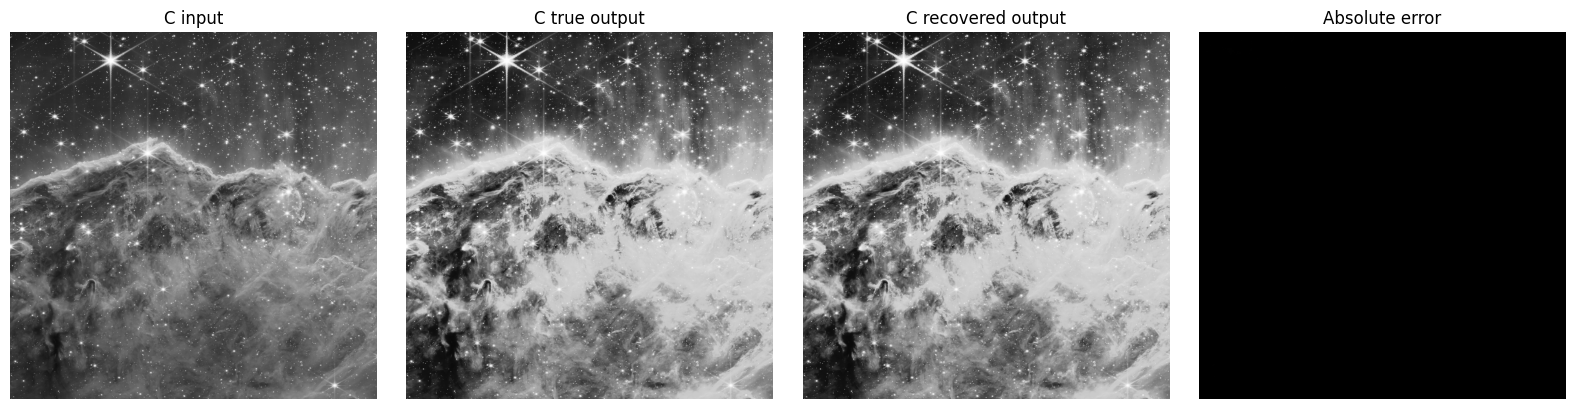

In [126]:
# Apply the selected C model and analyze reconstruction error.
C_recovered = apply_recovered(
    images["C_in"],
    bps_C,
    slopes_C,
    inter_C
)

err_C = reconstruction_error(
    C_recovered,
    images["C_out"]
)

print("C reconstruction error:")
print("Maximum absolute error:", err_C["max_abs_error"])
print("Mean absolute error:", f"{err_C['mean_abs_error']:.6f}")

error_image_C = np.abs(
    C_recovered.astype(np.int16) -
    images["C_out"].astype(np.int16)
)

max_error_location_C = np.unravel_index(
    np.argmax(error_image_C),
    error_image_C.shape
)

print("Maximum-error location:", max_error_location_C)
print("Input value:", images["C_in"][max_error_location_C])
print("True output:", images["C_out"][max_error_location_C])
print("Recovered output:", C_recovered[max_error_location_C])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for axis, image, title in zip(
    axes,
    (
        images["C_in"],
        images["C_out"],
        C_recovered,
        error_image_C,
    ),
    (
        "C input",
        "C true output",
        "C recovered output",
        "Absolute error",
    ),
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()

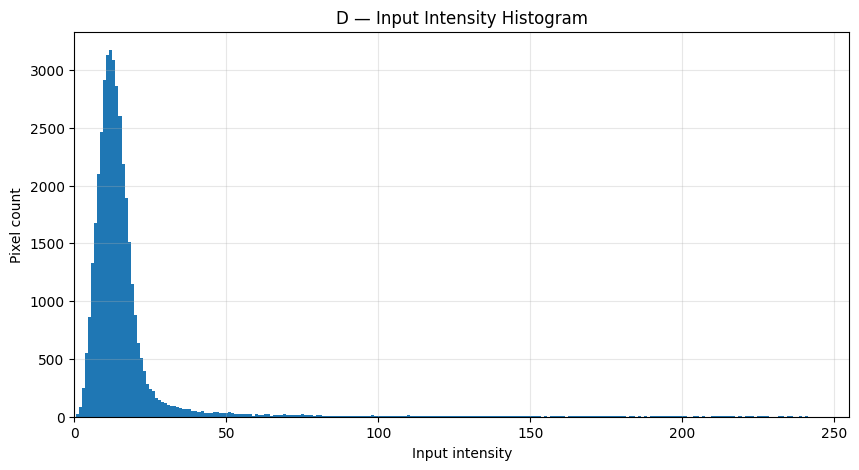

In [114]:
plt.figure(figsize=(10, 5))

levels = np.arange(256)

plt.bar(
    levels,
    cntD,
    width=1.0
)

plt.xlabel("Input intensity")
plt.ylabel("Pixel count")
plt.title("D — Input Intensity Histogram")
plt.xlim(0, 255)
plt.grid(True, alpha=0.3)

plt.show()

In [115]:
N_D = images["D_in"].size

print("Total pixels:", N_D)
print("Minimum nonzero count:", cntD[cntD > 0].min())
print("Maximum level count:", cntD.max())

Total pixels: 40000
Minimum nonzero count: 1
Maximum level count: 3173


In [116]:
support_fraction = 0.001

support_threshold = max(
    1,
    int(np.ceil(support_fraction * N_D))
)

print("Support fraction:", support_fraction)
print("Support threshold:", support_threshold)

Support fraction: 0.001
Support threshold: 40


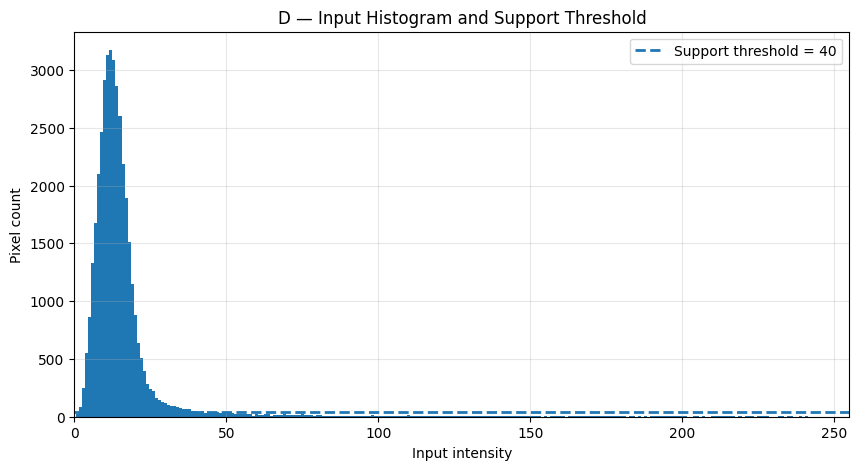

In [117]:
plt.figure(figsize=(10, 5))

plt.bar(
    levels,
    cntD,
    width=1.0
)

plt.axhline(
    support_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Support threshold = {support_threshold}"
)

plt.xlabel("Input intensity")
plt.ylabel("Pixel count")
plt.title("D — Input Histogram and Support Threshold")
plt.xlim(0, 255)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [118]:
def support_report(cnt, **kw):
    """
    Report intensity ranges whose pixel counts are below the support
    threshold.

    Parameters
    ----------
    cnt : array
        Pixel counts for each input intensity.

    Keyword arguments
    -----------------
    threshold : int, optional
        Minimum count required to trust T[v].
    fraction : float, optional
        Alternative way to specify threshold as a fraction of all pixels.

    Returns
    -------
    str
        Human-readable description of unsupported ranges.
    """

    cnt = np.asarray(cnt)

    if "threshold" in kw:
        threshold = int(kw["threshold"])

    elif "fraction" in kw:
        N = int(cnt.sum())
        threshold = max(
            1,
            int(np.ceil(kw["fraction"] * N))
        )

    else:
        raise ValueError(
            "Provide threshold= or fraction="
        )

    unsupported = cnt < threshold

    ranges = []

    start = None

    for v in range(256):

        if unsupported[v] and start is None:
            start = v

        elif not unsupported[v] and start is not None:
            ranges.append((start, v - 1))
            start = None

    if start is not None:
        ranges.append((start, 255))

    if not ranges:
        return f"All intensity levels meet the support threshold ({threshold})."

    parts = [
        f"{a}-{b}"
        for a, b in ranges
    ]

    return (
        f"Support threshold = {threshold} pixels.\n"
        f"Insufficiently supported intensity ranges: "
        + ", ".join(parts)
    )

In [119]:
print(
    support_report(
        cntD,
        threshold=support_threshold
    )
)

Support threshold = 40 pixels.
Insufficiently supported intensity ranges: 0-1, 43-46, 48-255


In [120]:
sampled = cntD > 0
supported = cntD >= support_threshold

sampled_levels = np.where(sampled)[0]
supported_levels = np.where(supported)[0]

print(
    "Actually sampled:",
    sampled_levels.min(),
    "to",
    sampled_levels.max()
)

print(
    "Well supported:",
    supported_levels.min(),
    "to",
    supported_levels.max()
)

Actually sampled: 0 to 246
Well supported: 2 to 47


In [121]:
TD_supported = TD.copy()
cntD_supported = cntD.copy()

weak = cntD_supported < support_threshold

TD_supported[weak] = np.nan
cntD_supported[weak] = 0

bps_D, slopes_D, inter_D, n_D = fit_piecewise(
    TD_supported,
    cntD_supported,
    max_seg=4
)

print("Reported segments:", n_D)
print("Breakpoints:", bps_D)
print("Slopes:", slopes_D)
print("Intercepts:", inter_D)

Reported segments: 2
Breakpoints: [np.int64(20)]
Slopes: [np.float64(1.5008093988195856), np.float64(4.876499801675441)]
Intercepts: [np.float64(-0.25631488201610253), np.float64(-68.19032697854828)]


In [122]:
def contiguous_ranges(mask):
    mask = np.asarray(mask, dtype=bool)
    ranges = []
    start = None

    for level, present in enumerate(mask):
        if present and start is None:
            start = level
        elif not present and start is not None:
            ranges.append((start, level - 1))
            start = None

    if start is not None:
        ranges.append((start, len(mask) - 1))

    return ranges


sampled_levels = cntD > 0
trusted_levels = cntD >= support_threshold
weak_levels = sampled_levels & ~trusted_levels
unidentifiable_levels = ~sampled_levels

print("(a) Actually sampled:", contiguous_ranges(sampled_levels))
print("(a) Trust threshold:", support_threshold, "pixels per input level")
print("(b) Trusted levels:", contiguous_ranges(trusted_levels))
print("(b) Weakly supported sampled levels:", contiguous_ranges(weak_levels))
print("(b) Unidentifiable levels:", contiguous_ranges(unidentifiable_levels))

supported_lo = int(np.where(trusted_levels)[0].min())
supported_hi = int(np.where(trusted_levels)[0].max())
segment_starts = [supported_lo] + [int(bp) + 1 for bp in bps_D]
segment_ends = [int(bp) for bp in bps_D] + [supported_hi]

print("(b) Recoverable segments:")
for index, (slope, intercept) in enumerate(zip(slopes_D, inter_D)):
    print(
        f"  {index + 1}: input {segment_starts[index]}-"
        f"{segment_ends[index]}, "
        f"slope={slope:.6f}, intercept={intercept:.6f}"
    )

print(
    f"(c) Reported {n_D} segment(s), not four: "
    "the crop contains enough support to identify only this portion "
    "of the transform."
)

(a) Actually sampled: [(0, 207), (210, 217), (219, 223), (225, 228), (230, 239), (241, 241), (244, 246)]
(a) Trust threshold: 40 pixels per input level
(b) Trusted levels: [(2, 42), (47, 47)]
(b) Weakly supported sampled levels: [(0, 1), (43, 46), (48, 207), (210, 217), (219, 223), (225, 228), (230, 239), (241, 241), (244, 246)]
(b) Unidentifiable levels: [(208, 209), (218, 218), (224, 224), (229, 229), (240, 240), (242, 243), (247, 255)]
(b) Recoverable segments:
  1: input 2-20, slope=1.500809, intercept=-0.256315
  2: input 21-47, slope=4.876500, intercept=-68.190327
(c) Reported 2 segment(s), not four: the crop contains enough support to identify only this portion of the transform.
